## Double Deep Q-Network (Double DQN)

Empíricamente se observa que el DQN estándar tiende a **sobreestimar** los valores Q. Esto ocurre porque la misma red selecciona la acción óptima **y** evalúa su valor.

**Double DQN** separa estas dos responsabilidades:
- **Red online** (`model`): decide cuál es la mejor acción y se entrena
- **Red target** (`target_model`): evalúa el valor de esa acción, se sincroniza cada `target_update_freq` episodios

El target de Bellman cambia de:
$$r + \\gamma \\max_{a'} Q_{\\theta}(s', a')$$
a:
$$r + \\gamma \\, Q_{\\theta^-}\\!\\left(s',\\, \\arg\\max_{a'} Q_{\\theta}(s', a')\\right)$$

## Transition y Memory (Replay Buffer)

In [1]:
import random
from collections import deque
from typing import Any, List, NamedTuple, Sequence, SupportsFloat, Union


class Transition(NamedTuple):
    """Representa la transición de un estado al siguiente."""
    prev_state: Any
    next_state: Any
    action: Any
    reward: SupportsFloat
    terminated: bool


class Memory:
    """Búfer de reproducción (replay buffer) de tamaño fijo."""

    def __init__(self, size: int):
        self.max_size = int(size)
        self.transitions: deque = deque(maxlen=self.max_size)

    def remember(self, transition: Transition):
        self.transitions.append(transition)

    def batch(self, n: int) -> List[Transition]:
        n = min(len(self.transitions), n)
        return random.sample(self.transitions, n)

    def __len__(self) -> int:
        return len(self.transitions)

    def __getitem__(self, key: Union[int, slice]) -> Union[Transition, Sequence[Transition]]:
        return self.transitions.__getitem__(key)


## Double DQN Agent

La única diferencia respecto al DQN estándar está en `learn()`: la red online elige la acción, la red target evalúa su valor. Cada `target_update_freq` episodios se sincronizan los pesos.

In [2]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


class QNetwork(nn.Module):
    """Red neuronal que aproxima la función Q.
    Entrada: estado (18 valores continuos)
    Salida: Q-value para cada acción (7 valores)
    """

    def __init__(self, n_obs, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_obs, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, n_actions),
        )

    def forward(self, x):
        return self.net(x)


class DoubleDQNAgent:
    """
    Agente Double Deep Q-Learning.
    - model        (online): selecciona la mejor acción y se entrena
    - target_model (target): evalúa el valor de esa acción, se actualiza cada N episodios
    """

    def __init__(self, n_obs, n_actions, gamma=0.95, lr=1e-3, batch_size=64,
                 memory_size=10_000, epsilon=1.0, epsilon_min=0.05,
                 epsilon_decay=0.995, target_update_freq=10):
        self.n_actions = n_actions
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.memory = Memory(size=memory_size)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = QNetwork(n_obs, n_actions).to(self.device)
        self.target_model = copy.deepcopy(self.model)
        self.target_model.eval()
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randrange(self.n_actions)
        state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.model(state_t)
        return int(q_values.argmax().item())

    def learn(self):
        """Target de Double DQN: online elige acción, target evalúa su valor."""
        if len(self.memory) < self.batch_size:
            return
        batch = self.memory.batch(self.batch_size)
        prev_states = torch.FloatTensor(np.array([t.prev_state for t in batch])).to(self.device)
        next_states = torch.FloatTensor(np.array([t.next_state for t in batch])).to(self.device)
        actions    = torch.LongTensor([t.action for t in batch]).to(self.device)
        rewards    = torch.FloatTensor([t.reward for t in batch]).to(self.device)
        terminated = torch.BoolTensor([t.terminated for t in batch]).to(self.device)

        qs = self.model(prev_states).gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            best_actions = self.model(next_states).argmax(1)
            next_qs = self.target_model(next_states).gather(1, best_actions.unsqueeze(1)).squeeze(1)
            next_qs[terminated] = 0.0
            targets = rewards + self.gamma * next_qs

        loss = self.loss_fn(qs, targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_target(self):
        """Copia los pesos de la red online a la red target."""
        self.target_model.load_state_dict(self.model.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def save(self, path):
        torch.save(self.model.state_dict(), path)

    def load(self, path):
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.update_target()
        self.model.eval()


## Entrenamiento Double DQN

Igual que en DQN, pero con `agent.update_target()` cada `target_update_freq` episodios.

In [ ]:
import os
import sys
import pandas as pd
from tqdm import tqdm

sys.path.append(os.path.abspath(".."))
from envs.continuous_parking_env import ContinuousParkingEnv


def train_double_dqn(episodes=1000, max_steps=300, warmup_steps=2000, gamma=0.95,
                     lr=1e-3, batch_size=64, memory_size=20_000,
                     epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.999,
                     target_update_freq=20):
    env = ContinuousParkingEnv(render_mode=None)
    agent = DoubleDQNAgent(
        n_obs=env.observation_space.shape[0],
        n_actions=env.action_space.n,
        gamma=gamma, lr=lr, batch_size=batch_size, memory_size=memory_size,
        epsilon=epsilon, epsilon_min=epsilon_min, epsilon_decay=epsilon_decay,
        target_update_freq=target_update_freq,
    )

    # --- Arranque en frío ---
    obs, _ = env.reset()
    for _ in range(warmup_steps):
        action = env.action_space.sample()
        next_obs, reward, terminated, truncated, _ = env.step(action)
        agent.memory.remember(Transition(
            prev_state=obs, next_state=next_obs,
            action=action, reward=reward, terminated=terminated,
        ))
        obs = next_obs
        if terminated or truncated:
            obs, _ = env.reset()

    # --- Bucle principal ---
    results = []
    for episode in tqdm(range(episodes), desc="Training DQN"):
        obs, info = env.reset()
        total_reward = 0.0
        success = False
        collision = False

        # Control de atasco
        last_x, last_y = obs[0], obs[1]
        stuck_steps = 0

        for step in range(max_steps):
            action = agent.select_action(obs)
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            # Detectar atasco: si no se mueve más de 0.01 en x ni en y durante 20 steps
            if abs(next_obs[0] - last_x) < 0.01 and abs(next_obs[1] - last_y) < 0.01:
                stuck_steps += 1
            else:
                stuck_steps = 0
                last_x, last_y = next_obs[0], next_obs[1]

            if stuck_steps >= 20:
                done = True

            agent.memory.remember(Transition(
                prev_state=obs,
                next_state=next_obs,
                action=action,
                reward=reward,
                terminated=terminated,
            ))

            if step % 4 == 0:
                agent.learn()

            obs = next_obs
            total_reward += reward

            if info["is_success"]:
                success = True
            if info["collision"]:
                collision = True

            if done:
                break

        agent.decay_epsilon()

        if episode % agent.target_update_freq == 0:
            agent.update_target()

        results.append({
            "episode": episode, "reward": total_reward,
            "success": int(success), "collision": int(collision),
            "steps": step + 1, "epsilon": agent.epsilon,
            "final_distance": info["distance_to_goal"],
        })

    env.close()
    os.makedirs("results", exist_ok=True)
    df = pd.DataFrame(results)
    df.to_csv("results/double_dqn_results.csv", index=False)
    agent.save("results/double_dqn_model.pt")
    print("Entrenamiento terminado.")
    return agent, df


agent, df = train_double_dqn()


Training DQN: 100%|██████████| 2000/2000 [22:26<00:00,  1.49it/s]


Entrenamiento terminado.


In [4]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import numpy as np
from IPython.display import display, clear_output

sys.path.append(os.path.abspath(".."))
from envs.continuous_parking_env import ContinuousParkingEnv


def plot_results(nombre, window=100):
    """Visualiza las métricas de entrenamiento de un algoritmo.
    nombre: clave del CSV (ej: 'dqn', 'double_dqn', 'dueling_dqn')
    """
    df = pd.read_csv(f"results/{nombre}_results.csv")

    df["reward_ma"]         = df["reward"].rolling(window).mean()
    df["success_ma"]        = df["success"].rolling(window).mean()
    df["collision_ma"]      = df["collision"].rolling(window).mean()
    df["steps_ma"]          = df["steps"].rolling(window).mean()
    df["final_distance_ma"] = df["final_distance"].rolling(window).mean()

    titulo = nombre.replace("_", " ").upper()

    metricas = [
        ("reward",         "Recompensa",              "Recompensa por episodio",    None),
        ("success",        "Tasa de éxito",           "Tasa de éxito",             (0, 1)),
        ("collision",      "Tasa de colisión",        "Colisiones",                (0, 1)),
        ("steps",          "Pasos",                   "Pasos por episodio",        None),
        ("final_distance", "Distancia final a plaza", "Distancia final al objetivo", None),
    ]

    for col, ylabel, subtitulo, ylim in metricas:
        plt.figure(figsize=(9, 4))
        if col == "reward":
            plt.plot(df["episode"], df[col], alpha=0.25, label=ylabel)
        plt.plot(df["episode"], df[f"{col}_ma"], label=f"{ylabel} media móvil {window}")
        plt.xlabel("Episodio")
        plt.ylabel(ylabel)
        plt.title(f"{titulo} - {subtitulo}")
        if ylim:
            plt.ylim(*ylim)
        plt.legend()
        plt.grid(True)
        plt.show()


def render_inline(env):
    """Renderiza el estado actual del entorno como figura inline en Jupyter."""
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_xlim(0, env.world_width)
    ax.set_ylim(0, env.world_height)
    ax.set_aspect("equal")
    ax.set_title("Entorno Parking Simulado")

    for ox, oy, ow, oh in env.obstacles:
        ax.add_patch(patches.Rectangle((ox, oy), ow, oh, color="steelblue", alpha=0.6))

    ax.add_patch(patches.Rectangle(
        (env.parking_center[0] - 0.4, env.parking_center[1] - 0.6),
        0.8, 1.2, fill=False, edgecolor="black", linewidth=2
    ))

    for relative_angle in env.sensor_angles:
        ray_angle = env.theta + relative_angle
        d = env._cast_ray(ray_angle)
        ax.plot([env.x, env.x + d * np.cos(ray_angle)],
                [env.y, env.y + d * np.sin(ray_angle)],
                linestyle="--", linewidth=0.8, color="gray")

    ax.plot(env.x, env.y, "o", markersize=10, color="steelblue")
    ax.arrow(env.x, env.y, 0.4 * np.cos(env.theta), 0.4 * np.sin(env.theta),
             head_width=0.15, length_includes_head=True, color="black")
    ax.grid(True, alpha=0.3)

    clear_output(wait=True)
    display(fig)
    plt.close(fig)


def visualizar_agente(nombre, model, max_steps=300):
    """Ejecuta un episodio mostrando el comportamiento del agente en el parking.
    nombre: nombre del algoritmo (ej: 'DQN', 'Double DQN', 'Dueling DQN')
    model:  red neuronal cargada con pesos entrenados, en modo eval()
    """
    device = next(model.parameters()).device

    def select_action(obs):
        state_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
        with torch.no_grad():
            return int(model(state_t).argmax().item())

    env = ContinuousParkingEnv(render_mode=None)
    obs, info = env.reset()

    print(f"\n--- Visualizando {nombre} ---")
    for step in range(max_steps):
        action = select_action(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        render_inline(env)
        if terminated or truncated:
            break

    status = "✅ Aparcado" if info["is_success"] else "💥 Colisión" if info["collision"] else "⏱ Tiempo agotado"
    print(f"Episodio terminado en {step+1} pasos — {status}")
    print(f"Distancia final a la plaza: {info['distance_to_goal']:.3f} m")
    env.close()


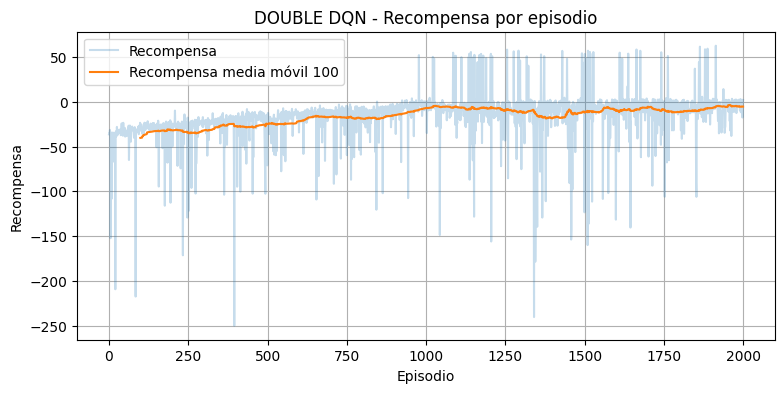

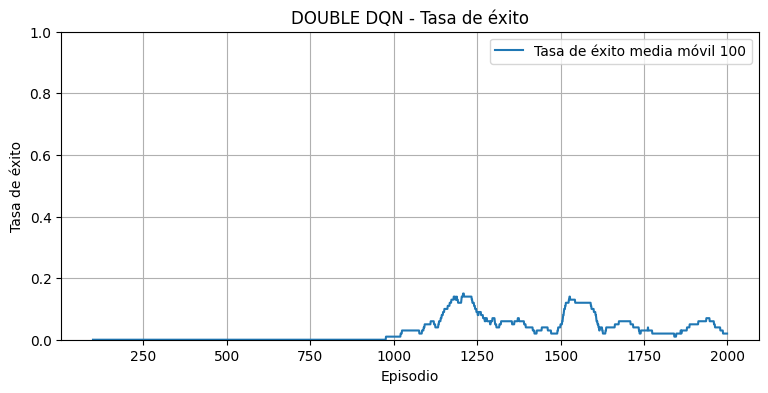

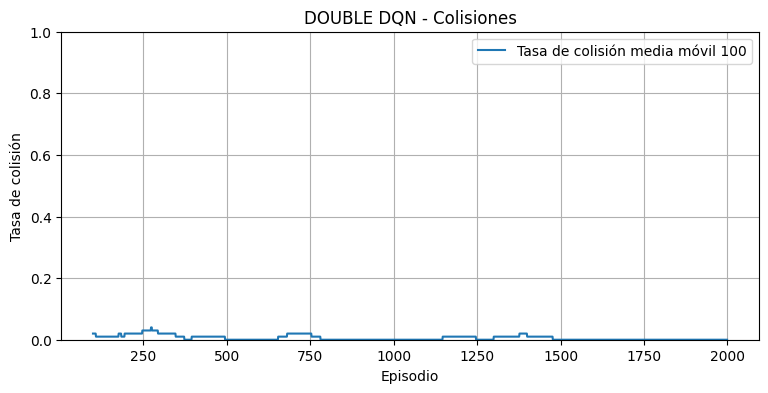

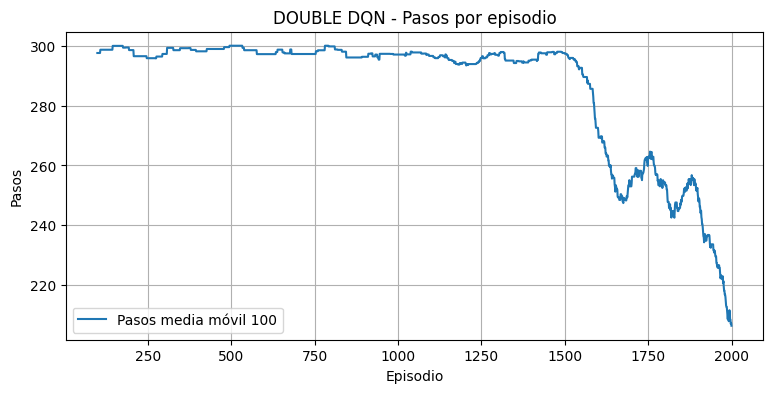

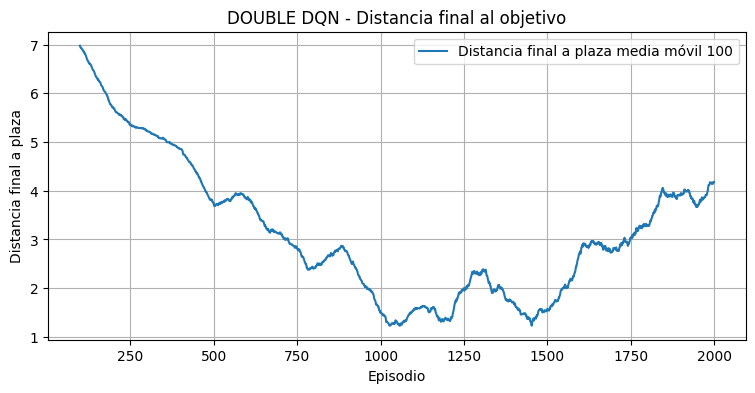

In [8]:

plot_results("double_dqn")

KeyboardInterrupt: 

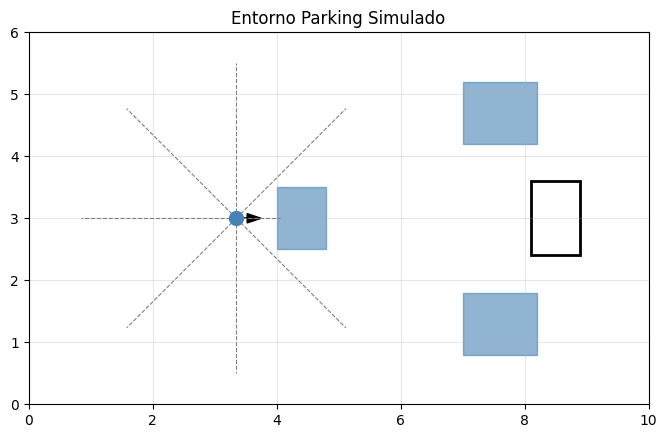

In [10]:
from neural_networks.networks import QNetwork

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_double = QNetwork(n_obs=18, n_actions=7).to(device)
model_double.load_state_dict(torch.load("results/double_dqn_model.pt", map_location=device))
model_double.eval()

for i in range(5):
    print(f"\n--- Episodio {i+1}/5 ---")
    visualizar_agente("Double DQN", model_double)
